In [1]:
%cd ../../

/home/hoanghu/projects/fw-models


In [2]:
import joblib
from itertools import permutations, product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from sklearn.preprocessing import TargetEncoder
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy import stats

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and resources

In [4]:
meals = pl.read_excel("data/processed/phase_4/dim_meals.xlsx")
meals.head()

meal_id,meal_type_1,schoolyear,is_kela,is_new,restaurant,meal_type_2,pcs_mean
i64,str,str,bool,bool,str,str,f64
9017,"""vegan""","""24-25""",true,true,"""che-exa-vik""","""vegan-miscellaneous""",116.3425
7201,"""vegan""","""23-24""",false,false,null,null,106.231119
9032,"""vegan""","""23-24""",false,false,null,null,106.231119
9102,"""vegan""","""23-24""",false,false,null,null,106.231119
7010,"""vegetarian""","""24-25""",false,false,"""che-exa-vik""",null,71.0


In [5]:
meal_names = pl.read_excel("data/processed/phase_4/dim_meal_names.xlsx")
meal_names.head()

meal_id,meal
i64,str
9017,"""""Butter"" härkäpapua & pähkinää"""
7201,"""2023 Härkäpu-sienilasagnette"""
9032,"""Appelisiini-luomukikhernecurry…"
9102,"""Artisokkavugetteja & tuoretoma…"
7010,"""Aurajuusto-pinaattilasagnette"""


In [6]:
dim_opentime = (
    pl
    .from_records([
        {'restaurant': 'che', 'time_open': '10:30', 'time_close': '15:00'},
        {'restaurant': 'exa', 'time_open': '11:00', 'time_close': '14:00'},
        {'restaurant': 'phy', 'time_open': '10:00', 'time_close': '15:00'},
        {'restaurant': 'vik', 'time_open': '10:30', 'time_close': '14:00'},
    ])
    .select(
        'restaurant',
        pl.col('time_open').str.to_datetime("%H:%M"),
        pl.col('time_close').str.to_datetime("%H:%M")
    )
    .with_columns(
        ((pl.col('time_close') - pl.col('time_open')).dt.total_minutes() / 60.).alias('working_duration')
    )
)

dim_opentime.head()

restaurant,time_open,time_close,working_duration
str,datetime[μs],datetime[μs],f64
"""che""",0001-01-01 10:30:00,0001-01-01 15:00:00,4.5
"""exa""",0001-01-01 11:00:00,0001-01-01 14:00:00,3.0
"""phy""",0001-01-01 10:00:00,0001-01-01 15:00:00,5.0
"""vik""",0001-01-01 10:30:00,0001-01-01 14:00:00,3.5


In [7]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)
pos.head()

column_1,column_2,column_3,column_4,column_5,column_6,column_7
str,str,str,str,str,i64,str
"""2.1.2023""","""10:31""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:35""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:36""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",2,"""1,8"""


In [8]:
# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che',
    '610 Physicum': 'phy',
    '620 Exactum': 'exa',
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )

    
    # Get meal_id
    .join(meal_names, on='meal', how='left')

    
    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)

# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
names_meal_type = {
    'meat':    '1', # 'meat',
    'fish':    '2', # 'fish',
    'vegan':    '3', # 'vegan',
    'vegetarian':    '4', # 'vegetarian',
    'chicken':    '5', # 'chicken'
}
meal_types = meals.select(
    'meal_id',
    pl.col('meal_type_1').alias('meal_type')
)
pos = (
    pos
    .join(meal_types, on='meal_id', how='left')

    # Ignore buffet
    .filter(pl.col('meal_type') != pl.lit('buffet'))

    # Encode
    .with_columns(pl.col('meal_type').replace_strict(names_meal_type).str.to_integer())
)



# Keep THETA most consumed meals per date-restaurant
THETA = 5
pos = (
    pos
    .with_columns(
        pl.col('pcs') + np.random.rand(len(pos)) * 1e-3
    )
    .with_columns(
        pl.col('pcs').rank(method="dense", descending=True).over(['date', 'restaurant'], order_by='pcs').alias('rank')
    )
    .filter(pl.col('rank') <= THETA)
    .drop('rank')
)



# Encode restaurant
names_restaurant = {
    'che': '1',
    'phy': '2',
    'exa': '3',
    'vik': '4',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant).str.to_integer())

pos = pos.to_pandas()

pos.head()

,restaurant,date,meal_id,pcs,serving_percent,meal_type
0,1,2023-01-09,9500030,259.000067,0.981481,1
1,1,2023-01-20,7007,246.000739,0.907407,3
2,2,2023-01-12,1445,7.000363,0.613333,4
3,2,2023-10-06,1509,25.000016,0.753333,5
4,2,2023-01-30,1454,17.000664,0.750000,4


# Encode features

Options:
- TargetEncoding for restaurant, meal_id

In [7]:
post_tmp = pos.copy()



# Create mutual information-aware dataset: add meals appearing in the same day for each record
def _tolist(s: pd.Series):
    out = s.tolist()

    return out

meal_ids = pos.groupby(['date', 'restaurant'])['meal_id'].apply(lambda x: _tolist(x))

records = []
for r in pos.itertuples():
    ids = set(meal_ids.loc[(r.date, r.restaurant)].copy())
    ids.remove(r.meal_id)
    
    for tup in permutations(ids):
        tup = [*tup]

        # pad
        if len(tup) < THETA - 1:
            tup.extend([0]*(THETA - 1 - len(tup)))
        
        records.append({
            'date': r.date,
            'restaurant': r.restaurant,
            'meal_id': r.meal_id,
            'meal_id_other1': tup[0],
            'meal_id_other2': tup[1],
            'meal_id_other3': tup[2],
            'meal_id_other4': tup[3],

            # 'meal_type': r.meal_type,
            'pcs': r.pcs
        })
pos = pd.DataFrame.from_records(records)



# Encode time
# pos.dropna(axis=0, how='any', inplace=True)
pos['weekday'] = pos['date'].dt.weekday
pos['day'] = pos['date'].dt.day
pos['month'] = pos['date'].dt.month

def _encode_date_cyclic(t, period_week: int = 7, period_day: int = 31, period_month: int = 12):
    def get_sin_encoding(x, period: int):
        return np.sin(2 * np.pi * x / period)
    def get_cos_encoding(x, period: int):
        return np.cos(2 * np.pi * x / period)  

    return pd.Series({
        'weekday_sin': get_sin_encoding(t.weekday(), period_week),
        'weekday_cos': get_cos_encoding(t.weekday(), period_week),
        'day_sin': get_sin_encoding(t.day, period_day),
        'day_cos': get_cos_encoding(t.day, period_day),
        'month_sin': get_sin_encoding(t.month, period_month),
        'month_cos': get_cos_encoding(t.month, period_month),
    })

datetime_encoded = pos['date'].apply(_encode_date_cyclic)
pos = pd.concat([pos, datetime_encoded], axis=1)



# Add column `rank` and `pcs_mean`
CUTOFF_DATE = pd.to_datetime("2024-09-01")
meal_info = (
    post_tmp[post_tmp['date'] < CUTOFF_DATE]
    .groupby(['meal_id', 'meal_type'])
    .agg({'pcs': ['mean', 'sum']})
    .reset_index()
    .rename(columns={'pcs': 'mean', 'meal_id': 'id', 'meal_type': 'type'})
)
meal_info.columns = ['id', 'type', 'mean', 'pcs_sum']
meal_info['r'] = meal_info['mean'].rank(ascending=False)
meal_info.drop(columns='pcs_sum', inplace=True)

pos = (
    pos
    .merge(meal_info, how='left', left_on=['meal_id'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type', 'mean': 'pcs_mean', 'r': 'rank'})

    .merge(meal_info, how='left', left_on=['meal_id_other1'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type_other1', 'mean': 'pcs_mean_other1', 'r': 'rank_other1'})

    .merge(meal_info, how='left', left_on=['meal_id_other2'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type_other2', 'mean': 'pcs_mean_other2', 'r': 'rank_other2'})

    .merge(meal_info, how='left', left_on=['meal_id_other3'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type_other3', 'mean': 'pcs_mean_other3', 'r': 'rank_other3'})

    .merge(meal_info, how='left', left_on=['meal_id_other4'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type_other4', 'mean': 'pcs_mean_other4', 'r': 'rank_other4'})
)
pos = pos[~pos['pcs_mean'].isna()].fillna(0)         # Filter out records having no `pcs_mean` and impute data



# Encode target
# scaler_tgt = MinMaxScaler()
# y_scaled = pd.Series(scaler_tgt.fit_transform(y.to_numpy().reshape(-1, 1)).squeeze(), index=y.index)



# Encode meal_type
enc_meal_type = TargetEncoder(target_type='continuous')
enc_meal_type.fit(pos['meal_type'].to_numpy().reshape(-1, 1), pos['pcs'])

pos['meal_type_enc'] = enc_meal_type.transform(pos['meal_type'].to_numpy().reshape(-1, 1))

cols = ['meal_type_other1', 'meal_type_other2', 'meal_type_other3', 'meal_type_other4']
for col in cols:
    encoded = enc_meal_type.transform(pos[[col]])
    mask = (pos[col] != 0).astype(np.int32)
    encoded = encoded.squeeze() * mask

    pos[f'{col}_enc'] = encoded



# Encode meal_id
enc_meal_id = TargetEncoder(target_type='continuous')
enc_meal_id.fit(pos['meal_id'].to_numpy().reshape(-1, 1), pos['pcs'])

pos['meal_id_enc'] = enc_meal_id.transform(pos[['meal_id']])

cols = ['meal_id_other1', 'meal_id_other2', 'meal_id_other3', 'meal_id_other4']
for col in cols:
    encoded = enc_meal_id.transform(pos[col].to_numpy().reshape(-1, 1))
    mask = (pos[col] != 0).astype(np.int32)
    encoded = encoded.squeeze() * mask

    pos[f'{col}_enc'] = encoded



# Encode restaurant
enc_restaurant = TargetEncoder(target_type='continuous')
enc_restaurant.fit(pos['restaurant'].to_numpy().reshape(-1, 1), pos['pcs'])

pos['restaurant_enc'] = enc_restaurant.transform(pos['restaurant'].to_numpy().reshape(-1, 1))



# Assign categorical column type
cols_cat = [
    # 'weekday',
    # 'day',
    # 'month',

    'restaurant',

    # 'meal_id',
    'meal_type',
    
    # 'meal_id_other1',
    # 'meal_id_other2',
    # 'meal_id_other3',
    # 'meal_id_other4',

    'meal_type_other1',
    'meal_type_other2',
    'meal_type_other3',
    'meal_type_other4',
]
for col in cols_cat:
    pos[col] = pos[col].astype('int')

pos.head()

/home/hoanghu/projects/fw-models/.venv/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but TargetEncoder was fitted without feature names
  warnings.warn(
/home/hoanghu/projects/fw-models/.venv/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but TargetEncoder was fitted without feature names
  warnings.warn(
/home/hoanghu/projects/fw-models/.venv/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but TargetEncoder was fitted without feature names
  warnings.warn(
/home/hoanghu/projects/fw-models/.venv/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but TargetEncoder was fitted without feature names
  warnings.warn(
/home/hoanghu/projects/fw-models/.venv/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but TargetEncoder was fitted without feature names
  warnings.warn(


,date,restaurant,meal_id,meal_id_other1,meal_id_other2,meal_id_other3,meal_id_other4,pcs,weekday,day,...,meal_type_other1_enc,meal_type_other2_enc,meal_type_other3_enc,meal_type_other4_enc,meal_id_enc,meal_id_other1_enc,meal_id_other2_enc,meal_id_other3_enc,meal_id_other4_enc,restaurant_enc
0,2023-01-02,1,9500055,6128,9500160,0,0,78,0,2,...,95.766250,67.746071,0.0,0.0,242.050693,179.264137,186.760448,0.0,0.0,153.976332
1,2023-01-02,1,9500055,9500160,6128,0,0,78,0,2,...,67.746071,95.766250,0.0,0.0,242.050693,186.760448,179.264137,0.0,0.0,153.976332
2,2023-01-02,1,6128,9500160,9500055,0,0,84,0,2,...,67.746071,108.903838,0.0,0.0,179.264137,186.760448,242.050693,0.0,0.0,153.976332
3,2023-01-02,1,6128,9500055,9500160,0,0,84,0,2,...,108.903838,67.746071,0.0,0.0,179.264137,242.050693,186.760448,0.0,0.0,153.976332
4,2023-01-02,1,9500160,6128,9500055,0,0,165,0,2,...,95.766250,108.903838,0.0,0.0,186.760448,179.264137,242.050693,0.0,0.0,153.976332


# Predict

Nov 7: Use cut-off date at 2024-10-01

In [8]:
train = pos[pos['date'] < CUTOFF_DATE].copy()
val = pos[(pos['date'] >= CUTOFF_DATE) & (pos['date'] <= pd.to_datetime("2024-05-31"))].copy()

cols_X = [
    # 'weekday',
    # 'day',
    # 'month',

    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos',

    'restaurant',
    # 'restaurant_enc',

    # 'meal_id',
    'meal_id_enc',
    'meal_type',
    # 'meal_type_enc',
    # 'rank',
    'pcs_mean',

    # 'meal_id_other1',
    # 'meal_id_other2',
    # 'meal_id_other3',
    # 'meal_id_other4',
    'meal_id_other1_enc',
    'meal_id_other2_enc',
    'meal_id_other3_enc',
    'meal_id_other4_enc',

    'meal_type_other1',
    'meal_type_other2',
    'meal_type_other3',
    'meal_type_other4',
    # 'meal_type_other1_enc',
    # 'meal_type_other2_enc',
    # 'meal_type_other3_enc',
    # 'meal_type_other4_enc',

    # 'rank_other1',
    # 'rank_other2',
    # 'rank_other3',
    # 'rank_other4',

    'pcs_mean_other1',
    'pcs_mean_other2',
    'pcs_mean_other3',
    'pcs_mean_other4',
]
col_y = 'pcs'

Xtrain, ytrain = train[cols_X], train[col_y]
Xval, yval = val[cols_X], val[col_y]

Xtrain.head()


,weekday_sin,weekday_cos,day_sin,day_cos,month_sin,month_cos,restaurant,meal_id_enc,meal_type,pcs_mean,...,meal_id_other3_enc,meal_id_other4_enc,meal_type_other1,meal_type_other2,meal_type_other3,meal_type_other4,pcs_mean_other1,pcs_mean_other2,pcs_mean_other3,pcs_mean_other4
0,0.0,1.0,0.394356,0.918958,0.5,0.866025,1,242.050693,2,236.153846,...,0.0,0.0,3,1,0,0,155.458333,238.694444,0.0,0.0
1,0.0,1.0,0.394356,0.918958,0.5,0.866025,1,242.050693,2,236.153846,...,0.0,0.0,1,3,0,0,238.694444,155.458333,0.0,0.0
2,0.0,1.0,0.394356,0.918958,0.5,0.866025,1,179.264137,3,155.458333,...,0.0,0.0,1,2,0,0,238.694444,236.153846,0.0,0.0
3,0.0,1.0,0.394356,0.918958,0.5,0.866025,1,179.264137,3,155.458333,...,0.0,0.0,2,1,0,0,236.153846,238.694444,0.0,0.0
4,0.0,1.0,0.394356,0.918958,0.5,0.866025,1,186.760448,1,238.694444,...,0.0,0.0,3,2,0,0,155.458333,236.153846,0.0,0.0


In [9]:
# reg = CatBoostRegressor(verbose=False, cat_features=cols_cat)
# reg = LGBMRegressor(verbose=0)
# reg = XGBRegressor(
#     # **params,

#     tree_method="approx",
#     enable_categorical=True,
# )

# params = {
#     # 'tree_method': 'hist',
#     'eta': 0.145785914938231,
#     'max_depth': 5,
#     'lambda': 5.321488507451879,
#     'alpha': 4.394254450853125,
#     # 'enable_categorical': True,

# }

models = {
    # 'RF': {'model': RandomForestRegressor()},
    # 'GB': {'model': GradientBoostingRegressor()},
    'XGB':      {'model': XGBRegressor(), 'is_cat': False},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0), 'is_cat': True},
    # 'Voting': {'model': VotingRegressor([
    #     ('lightgbm', LGBMRegressor(verbose=0)),
    #     ('xgboost', XGBRegressor(tree_method="hist", enable_categorical=True)),
    #     ('cat', CatBoostRegressor(verbose=False, cat_features=cols_cat)),
    #     # ('ridge', Ridge()),
    #     # ('svr', SVR()),
    #     # ('gbr', GradientBoostingRegressor()),
    #     ('rf', RandomForestRegressor())
    # ])},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()
    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

# reg.fit(Xtrain, ytrain)


Start: XGB
Start: XGB-cat
Start: CatBoost
Start: LBGM
Start: LBGM-cat


# Evaluate

## Error metrics

In [11]:
metrics_models = []

def calc_metrics(split: pd.DataFrame, model: dict, verbose: bool = False) -> tuple:
    X = split[cols_X].copy()
    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    split['pcs_pred'] = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    split = (
        split
        .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
        .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
        .reset_index()
    )
    
    
    rmse = root_mean_squared_error(split['pcs'], split['pcs_pred']).item()
    r2 = r2_score(split['pcs'], split['pcs_pred'])

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"r2  : {r2:.4f}")

    return rmse, r2

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'val', 'metric': 'r2'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'train', 'metric': 'r2'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'r2'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")


== Split: val
Start: XGB


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
metrics[(metrics['split'] == 'val') & (metrics['metric'] == 'rmse')]

,model,val,split,metric
0,XGB,49.564889,val,rmse
2,XGB-cat,48.166877,val,rmse
4,CatBoost,46.608842,val,rmse
6,LBGM,46.585636,val,rmse
8,LBGM-cat,46.323979,val,rmse


In [ ]:
metrics[(metrics['split'] == 'val') & (metrics['metric'] == 'r2')]

,model,val,split,metric
1,XGB,0.744712,val,r2
3,XGB-cat,0.758910,val,r2
5,CatBoost,0.774255,val,r2
7,LBGM,0.774479,val,r2
9,LBGM-cat,0.777006,val,r2


In [ ]:
val_1317 = val[val['meal_id'] == 1317]

# calc_metrics(val_1317, reg)
for name, model in models.items():
    print(f"Start: {name}")

    calc_metrics(val_1317, model, verbose=True)

Start: XGB
rmse: 34.4777
r2  : -9.7819
Start: XGB-cat
rmse: 89.6938
r2  : -71.9703
Start: CatBoost
rmse: 19.0051
r2  : -2.2761
Start: LBGM
rmse: 15.0017
r2  : -1.0413
Start: LBGM-cat
rmse: 14.8210
r2  : -0.9924


/tmp/ipykernel_124614/2848953332.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split['pcs_pred'] = np.clip(model['model'].predict(X), a_min=0, a_max=None)
/tmp/ipykernel_124614/2848953332.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split['pcs_pred'] = np.clip(model['model'].predict(X), a_min=0, a_max=None)
/tmp/ipykernel_124614/2848953332.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

## Visualization-based

<Axes: xlabel='importance', ylabel='name'>

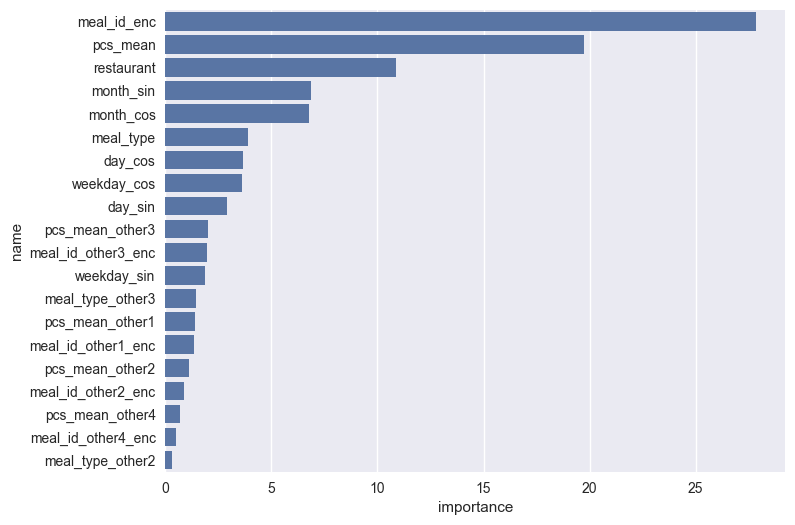

In [ ]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['CatBoost']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:20], y='name', x='importance', ax=ax)

In [ ]:
def visualize(split: pd.DataFrame, model: dict, dim: str):
    # Extract data
    X = split[cols_X].copy()
    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')


    split['pcs_pred'] = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    pcs_by_dim = (
        split
        .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
        .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
        .reset_index()
        .rename(columns={'pcs': 'gt', 'pcs_pred': 'pred'})
        .melt(id_vars=[dim], value_vars=['gt', 'pred'], var_name='type')
    )

    # Plot
    fig = plt.figure(figsize=(12, 25))

    # Plot overall
    pcs_gt, pcs_pred = pcs_by_dim[pcs_by_dim['type'] == 'gt']['value'], pcs_by_dim[pcs_by_dim['type'] == 'pred']['value']
    pval = stats.kstest(pcs_gt, pcs_pred).pvalue

    ax = fig.add_subplot(7, 1, 1)
    sns.kdeplot(pcs_by_dim, x='value', hue='type', ax=ax, fill=True)
    ax.set_title(f"Overall | p = {pval:.4f}")


    # Plot per-meal_type
    for idx, dim_val in enumerate(pcs_by_dim[dim].unique()):
        pcs = pcs_by_dim[pcs_by_dim[dim] == dim_val]


        # Test with KS-test
        pcs_gt, pcs_pred = pcs[pcs['type'] == 'gt']['value'], pcs[pcs['type'] == 'pred']['value']
        pval = stats.kstest(pcs_gt, pcs_pred).pvalue


        ax = fig.add_subplot(7, 2, idx + 3)
        # sns.histplot(pcs, x='value', hue='type', ax=ax, fill=True)
        sns.kdeplot(pcs, x='value', hue='type', ax=ax, fill=True)
        ax.set_title(f"{dim_val} | p = {pval:.4f}")
        ax.set(xlabel=None)
        ax.get_yaxis().set_visible(False)


### train-meal_type

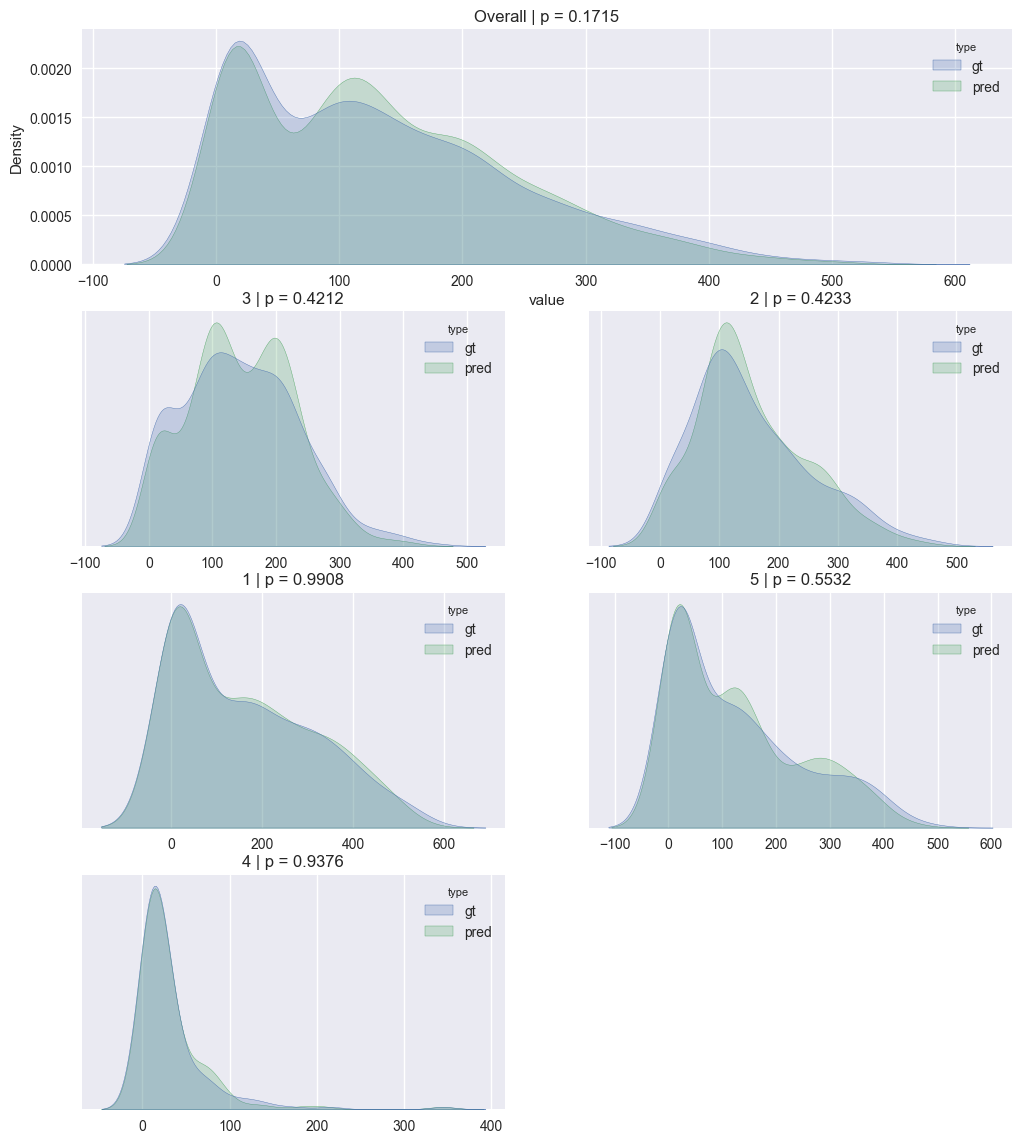

In [ ]:
visualize(train, models['CatBoost'] , 'meal_type')

### train-restaurant

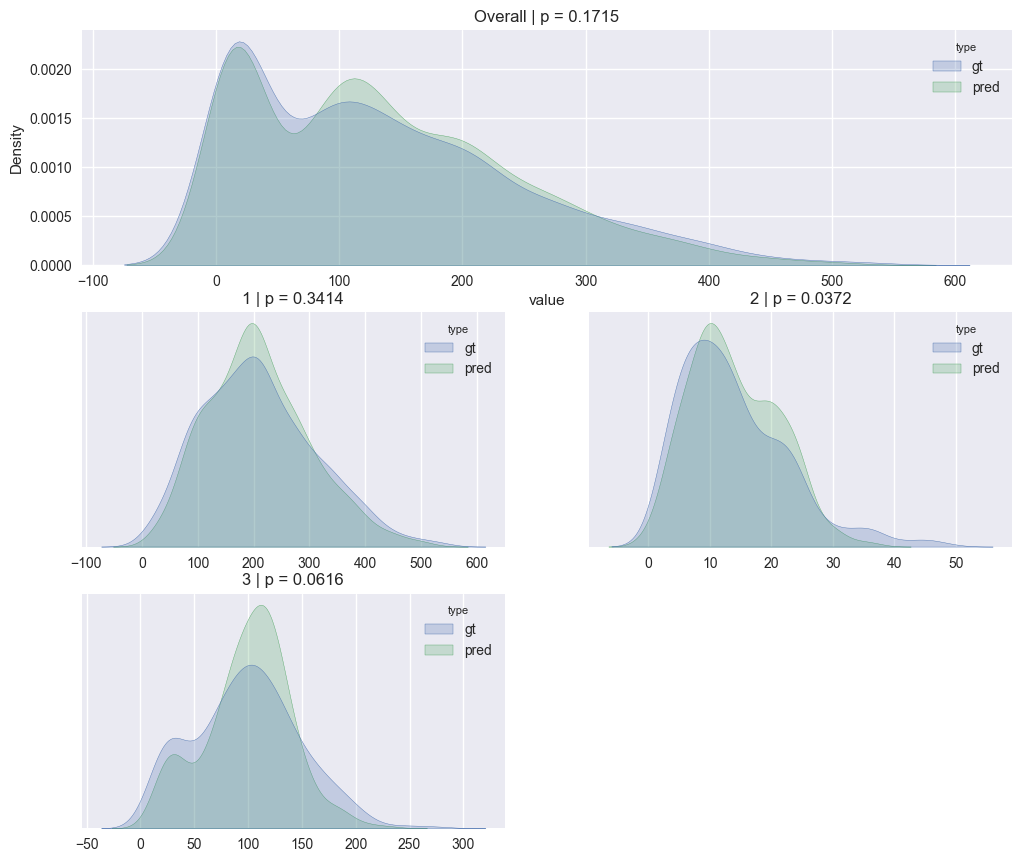

In [ ]:
visualize(train, models['CatBoost'] , 'restaurant')

### val-meal_type

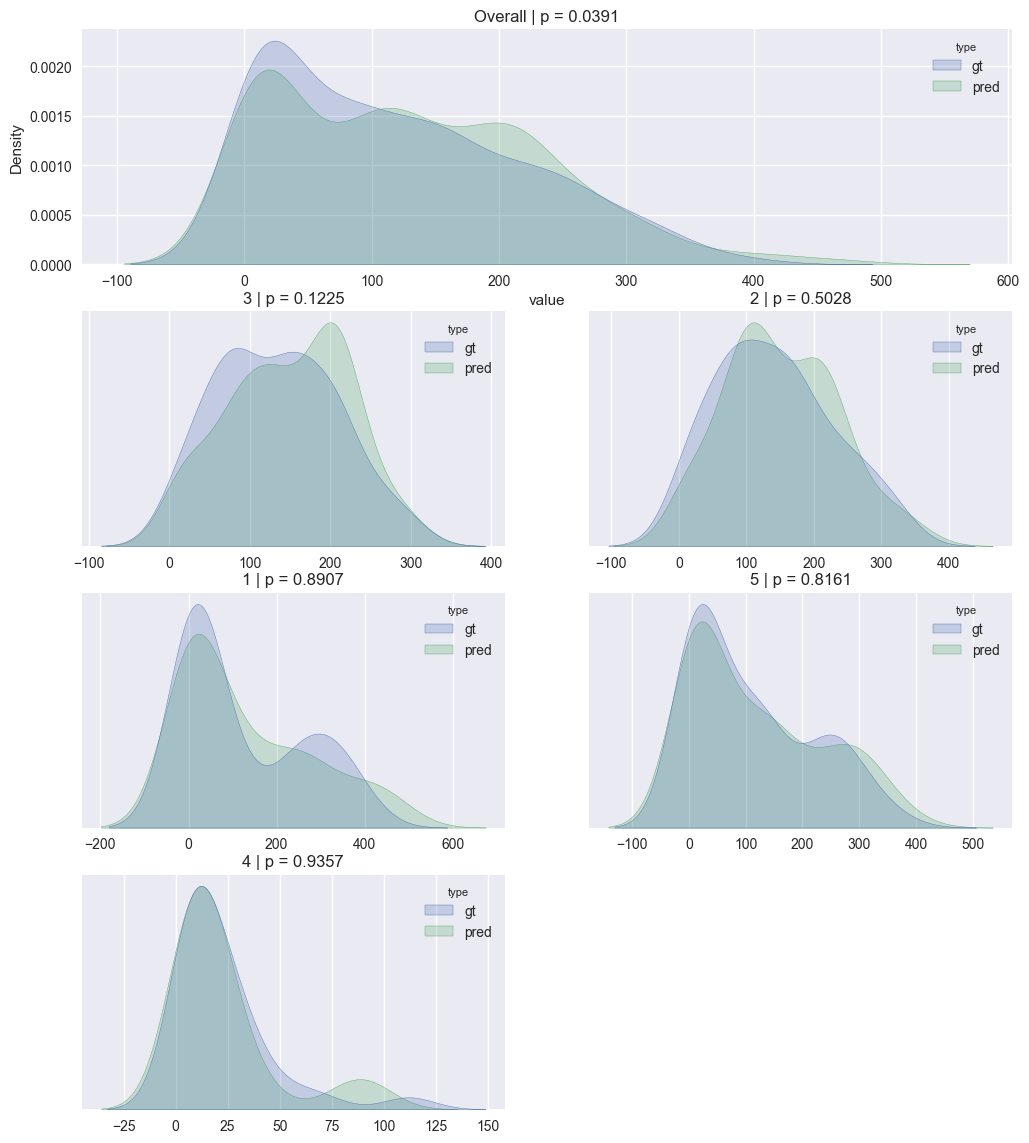

In [ ]:
visualize(val, models['XGB-cat'] , 'meal_type')

### val-restaurant

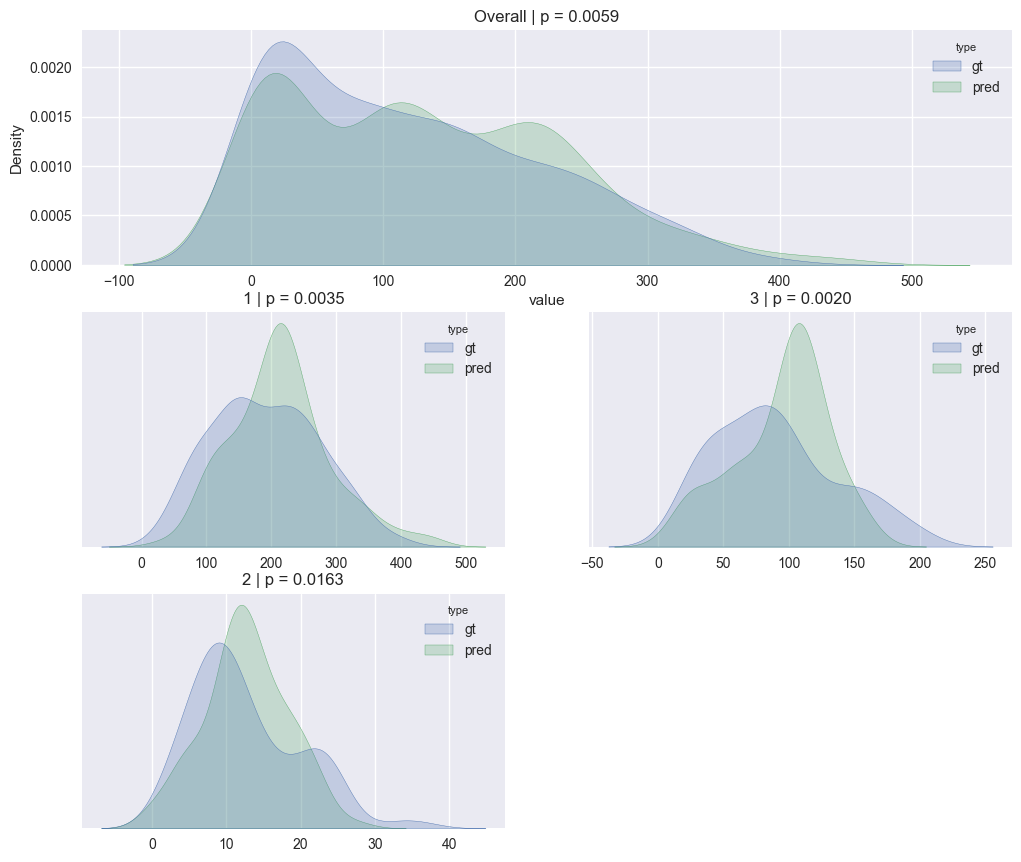

In [ ]:
visualize(val, models['CatBoost'] , 'restaurant')

# Tune

In [ ]:
# def objective(trial):

#     params = {
#         'tree_method': trial.suggest_categorical('tree_method', ["approx", 'hist']),
#         'enable_categorical': True,

#         'eta': trial.suggest_float('eta', 0.01, 0.4),
#         # 'gamma'
#         'max_depth': trial.suggest_int("max_depth", 3, 10),
#         'lambda': trial.suggest_float('lambda', 1, 10),
#         'alpha': trial.suggest_float('alpha', 1, 10),
#     }

#     reg = XGBRegressor(**params)

#     X = Xtrain.copy()

#     split = val.copy() 
#     Xval = split[cols_X].copy()

#     for col in cols_cat:
#         X[col] = X[col].astype('category')
#         Xval[col] = Xval[col].astype('category')

#     reg.fit(X, ytrain)

#     split['pcs_pred'] = np.clip(reg.predict(Xval), a_min=0, a_max=None)
#     split = (
#         split
#         .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
#         .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
#         .reset_index()
#     )

#     rmse = root_mean_squared_error(split['pcs'], split['pcs_pred']).item()
    
#     return rmse


# study = optuna.create_study(direction="minimize")

# # Optimize the objective function
# study.optimize(objective, n_trials=100)

In [ ]:
# params = {
#     'tree_method': 'hist',
#     'enable_categorical': True,
#  'eta': 0.15429529252045587,
#  'max_depth': 5,
#  'lambda': 4.912699955811186,
#  'alpha': 6.278417598129022
# }

# reg = XGBRegressor(**params)

# X = Xtrain.copy()

# split = val.copy() 
# Xval = split[cols_X].copy()

# for col in cols_cat:
#     X[col] = X[col].astype('category')
#     Xval[col] = Xval[col].astype('category')

# reg.fit(X, ytrain)

# split['pcs_pred'] = np.clip(reg.predict(Xval), a_min=0, a_max=None)
# split = (
#     split
#     .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
#     .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
#     .reset_index()
# )

# rmse = root_mean_squared_error(split['pcs'], split['pcs_pred']).item()
# r2 = r2_score(split['pcs'], split['pcs_pred'])

# print(f"rmse: {rmse:.4f}")
# print(f"r2  : {r2:.4f}")

# Train model with all data

### Tailor the data again

In [ ]:
pos = pos_raw.copy()


# Process meal_type
pos['meal_type'] = pos['meal_type'].map({
    'meat':    1, # 'meat',
    'fish':    2, # 'fish',
    'vegan':    3, # 'vegan',
    'vegetarian':    4, # 'vegetarian',
    'chicken':    5, # 'chicken'
})


# Process restaurant
pos['restaurant'] = pos['restaurant'].map({
    'che': 1, #'chemicum',
    'phy': 2, #'physicum',
    'exa': 3, #'exactum'
})


# Remove POS of leftover
DELTA = 3
pos['date_prev'] = (
    pos
    .sort_values('date')
    .groupby(['meal_id'])['date']
    .shift(1)    
)
pos = pos[
    (pos['date_prev'].isna())
    | ((pos['date'] - pos['date_prev']).dt.days > DELTA)
]
pos.drop(columns=['date_prev'], inplace=True)


# Keep THETA most consumed meals per date-restaurant
THETA = 5
pos['rank'] = pos.groupby(['date', 'restaurant'])['pcs'].rank(method="first", ascending=False)
pos = pos[pos['rank'] <= THETA]
pos.drop(columns=['rank'], inplace=True)


post_tmp = pos.copy()




# Create mutual information-aware dataset: add meals appearing in the same day for each record
def _tolist(s: pd.Series):
    out = s.tolist()

    return out

meal_ids = pos.groupby(['date', 'restaurant'])['meal_id'].apply(lambda x: _tolist(x))

records = []
for r in pos.itertuples():
    ids = set(meal_ids.loc[(r.date, r.restaurant)].copy())
    ids.remove(r.meal_id)
    
    for tup in permutations(ids):
        tup = [*tup]

        # pad
        if len(tup) < THETA - 1:
            tup.extend([0]*(THETA - 1 - len(tup)))
        
        records.append({
            'date': r.date,
            'restaurant': r.restaurant,
            'meal_id': r.meal_id,
            'meal_id_other1': tup[0],
            'meal_id_other2': tup[1],
            'meal_id_other3': tup[2],
            'meal_id_other4': tup[3],

            # 'meal_type': r.meal_type,
            'pcs': r.pcs
        })
pos = pd.DataFrame.from_records(records)



# Encode time
def _encode_date_cyclic(t, period_week: int = 7, period_day: int = 31, period_month: int = 12):
    def get_sin_encoding(x, period: int):
        return np.sin(2 * np.pi * x / period)
    def get_cos_encoding(x, period: int):
        return np.cos(2 * np.pi * x / period)  

    return pd.Series({
        'weekday_sin': get_sin_encoding(t.weekday(), period_week),
        'weekday_cos': get_cos_encoding(t.weekday(), period_week),
        'day_sin': get_sin_encoding(t.day, period_day),
        'day_cos': get_cos_encoding(t.day, period_day),
        'month_sin': get_sin_encoding(t.month, period_month),
        'month_cos': get_cos_encoding(t.month, period_month),
    })

datetime_encoded = pos['date'].apply(_encode_date_cyclic)
pos = pd.concat([pos, datetime_encoded], axis=1)



# Add column `mean`
meal_info = (
    post_tmp
    .groupby(['meal_id', 'meal_type'])
    .agg({'pcs': 'mean'})
    .reset_index()
    .rename(columns={'pcs': 'mean', 'meal_id': 'id', 'meal_type': 'type'})
)
meal_info.columns = ['id', 'type', 'mean']

pos = (
    pos
    .merge(meal_info, how='left', left_on=['meal_id'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type', 'mean': 'pcs_mean'})

    .merge(meal_info, how='left', left_on=['meal_id_other1'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type_other1', 'mean': 'pcs_mean_other1'})

    .merge(meal_info, how='left', left_on=['meal_id_other2'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type_other2', 'mean': 'pcs_mean_other2'})

    .merge(meal_info, how='left', left_on=['meal_id_other3'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type_other3', 'mean': 'pcs_mean_other3'})

    .merge(meal_info, how='left', left_on=['meal_id_other4'], right_on=['id'])
    .drop(columns='id')
    .rename(columns={'type': 'meal_type_other4', 'mean': 'pcs_mean_other4'})
)
pos = pos[~pos['pcs_mean'].isna()].fillna(0)         # Filter out records having no `pcs_mean` and impute data


# Encode meal_id
enc_meal_id = TargetEncoder(target_type='continuous')
enc_meal_id.fit(pos['meal_id'].to_numpy().reshape(-1, 1), pos['pcs'])

pos['meal_id_enc'] = enc_meal_id.transform(pos[['meal_id']])

cols = ['meal_id_other1', 'meal_id_other2', 'meal_id_other3', 'meal_id_other4']
for col in cols:
    encoded = enc_meal_id.transform(pos[col].to_numpy().reshape(-1, 1))
    mask = (pos[col] != 0).astype(np.int32)
    encoded = encoded.squeeze() * mask

    pos[f'{col}_enc'] = encoded



# Encode restaurant
enc_restaurant = TargetEncoder(target_type='continuous')
enc_restaurant.fit(pos['restaurant'].to_numpy().reshape(-1, 1), pos['pcs'])

pos['restaurant_enc'] = enc_restaurant.transform(pos['restaurant'].to_numpy().reshape(-1, 1))



# Assign categorical column type
cols_cat = [
    'restaurant',

    'meal_type',

    'meal_type_other1',
    'meal_type_other2',
    'meal_type_other3',
    'meal_type_other4',
]
for col in cols_cat:
    pos[col] = pos[col].astype('category')

pos.head()

/home/hoanghu/projects/Food-Waste-Optimization/.venv/lib/python3.10/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but TargetEncoder was fitted without feature names
  warnings.warn(


,date,restaurant,meal_id,meal_id_other1,meal_id_other2,meal_id_other3,meal_id_other4,pcs,weekday_sin,weekday_cos,...,meal_type_other3,pcs_mean_other3,meal_type_other4,pcs_mean_other4,meal_id_enc,meal_id_other1_enc,meal_id_other2_enc,meal_id_other3_enc,meal_id_other4_enc,restaurant_enc
0,2023-01-02,1,9500047,6128,9500139,0,0,78,0.0,1.0,...,0.0,0.0,0.0,0.0,223.719787,181.963720,199.625513,0.0,0.0,155.056072
1,2023-01-02,1,9500047,9500139,6128,0,0,78,0.0,1.0,...,0.0,0.0,0.0,0.0,223.719787,199.625513,181.963720,0.0,0.0,155.056072
2,2023-01-02,1,6128,9500139,9500047,0,0,84,0.0,1.0,...,0.0,0.0,0.0,0.0,181.963720,199.625513,223.719787,0.0,0.0,155.056072
3,2023-01-02,1,6128,9500047,9500139,0,0,84,0.0,1.0,...,0.0,0.0,0.0,0.0,181.963720,223.719787,199.625513,0.0,0.0,155.056072
4,2023-01-02,1,9500139,6128,9500047,0,0,165,0.0,1.0,...,0.0,0.0,0.0,0.0,199.625513,181.963720,223.719787,0.0,0.0,155.056072


In [ ]:
cols_X = [
    'weekday_sin',
    'weekday_cos',
    'day_sin',
    'day_cos',
    'month_sin',
    'month_cos',

    'restaurant',

    'meal_id_enc',
    'meal_type',

    'pcs_mean',

    'meal_id_other1_enc',
    'meal_id_other2_enc',
    'meal_id_other3_enc',
    'meal_id_other4_enc',

    'meal_type_other1',
    'meal_type_other2',
    'meal_type_other3',
    'meal_type_other4',

    'pcs_mean_other1',
    'pcs_mean_other2',
    'pcs_mean_other3',
    'pcs_mean_other4',
]
col_y = 'pcs'

X, y = pos[cols_X], pos[col_y]


## Train model

In [ ]:
reg = XGBRegressor(tree_method="hist", enable_categorical=True)

reg.fit(X, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

## Store trained model and encoder

In [ ]:
path = "trained_models/pos/phase_4/xgb_cat_Nov13.json"
reg.save_model(path)

In [ ]:
path = "trained_models/encoder/phase_4/targetenc_meal_id_Nov13.pkl"

joblib.dump(enc_meal_id, path)

['trained_models/encoder/phase_4/targetenc_meal_id_Nov13.pkl']